In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import dask.dataframe as dd

/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [2]:
# plot Function
def plot_burstiness(result1):
    # Example burst data
    start_times = result1['ts']
    end_times = result1['te']
    counts = result1['count']

    # Bar width = end - start
    widths = [end - start for start, end in zip(start_times, end_times)]

    # All bars at y=0 since burst ID doesn't matter
    y_position = [0] * len(start_times)

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 3))

    for i in range(len(start_times)):
        ax.bar(
            x=start_times[i],     # left edge of the bar
            height=counts[i],     # height of the bar = count
            width=widths[i],      # width = end - start
            bottom=0,
            align='edge',
            edgecolor='black',
            alpha=0.7,
            label=f"Burst {i+1}",
            color='steelblue'
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Count")
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.set_title("I/O Burst Ranges Over Time")
    # ax.legend()
    # plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()


def plot_burstiness1(result1):
    start_times = result1['ts']
    end_times = result1['te']
    counts = result1['count']
    sizes = result1['size']

    # Bar width = end - start
    widths = [end - start for start, end in zip(start_times, end_times)]

    fig, ax1 = plt.subplots(figsize=(10, 4))

    # Bar plot for burst count
    for i in range(len(start_times)):
        ax1.bar(
            x=start_times[i],
            height=counts[i],
            width=widths[i],
            bottom=0,
            align='edge',
            edgecolor='black',
            alpha=0.7,
            color='steelblue'
        )

    ax1.set_xlabel("Time")
    ax1.set_ylabel("Count", color='steelblue')
    ax1.tick_params(axis='y', labelcolor='steelblue')
    ax1.grid(True, axis='y', linestyle='--', alpha=0.5)

    # Line plot for size on a second y-axis
    ax2 = ax1.twinx()
    mid_points = [(s + e) / 2 for s, e in zip(start_times, end_times)]
    ax2.plot(mid_points, sizes, color='darkorange', marker='o', label='Size')
    ax2.set_ylabel("Size", color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

    plt.title("I/O Burst Ranges Over Time (Counts & Size)")
    plt.tight_layout()
    plt.show()

# Merge Results:
def merge_close_bursts(result_df):
    """
    Merge bursts in the DataFrame if the time between the end of one burst
    and the start of the next is less than the standard deviation of all such gaps.
    
    Parameters:
    - result_df: DataFrame with columns ['b_id', 'start_time', 'end_time', 'dur', 'size', 'count']
    
    Returns:
    - merged_result: DataFrame with merged bursts
    """

    # Step 1: Sort by start_time
    result_df = result_df.sort_values('start_time').reset_index(drop=True)

            # Make sure these are int64 or float64 and not Arrow timestamp types
    result_df['start_time'] = result_df['start_time'].astype('int64')
    result_df['end_time'] = result_df['end_time'].astype('int64')

    # Step 2: Compute time gap between current end_time and next start_time
    result_df['gap'] = result_df['start_time'].shift(-1) - result_df['end_time']

    # Step 3: Calculate std of gaps, excluding the last row (gap=NaN)
    gap_std = result_df['gap'].dropna().std()

    # Step 4: Assign group IDs based on the std threshold
    group_id = 0
    group_ids = [group_id]
    for i in range(1, len(result_df)):
        if result_df.loc[i - 1, 'gap'] < gap_std:
            group_ids.append(group_id)
        else:
            group_id += 1
            group_ids.append(group_id)
    result_df['group_id'] = group_ids

    # Step 5: Merge the groups
    merged_result = result_df.groupby('group_id').agg(
        start_time=('start_time', 'min'),
        end_time=('end_time', 'max'),
        dur=('dur', 'sum'),
        size=('size', 'sum'),
        count=('count', 'sum')
    ).reset_index(drop=True)

    return merged_result


In [3]:
# app_name = "resnet50"
app_name = "cm1"
identifier = "ddf_bur-data"
cp_dir = "/p/lustre3/pandey2/logs/Results_Checkpoint"
read_df = dd.read_parquet(f"{cp_dir}/{app_name}/{identifier}*.parquet")


In [4]:
def add_partition_id(df, partition_info=None):
    partition_number = partition_info['number']
    df['b_id'] = df['b_id'].astype(str) + f"__p{partition_number}"
    return df

ddf = read_df.map_partitions(add_partition_id, meta=read_df)


In [5]:
df = ddf.compute()

In [ ]:
# selected_events = df[
#     (df['mount_point'] == "/p/lustre3") & (df['name'] == "pread")
#  ].reset_index(drop=True)

In [ ]:
# selected_events.head()

,id,name,cat,size,ts,te,dur,trange,mount_point,hostname,group_key,b_id
0,302889,pread,POSIX,262144,360185465,360185510,45,12,/p/lustre3,corona189,"(12, '/p/lustre3')",302889
1,69263,pread,POSIX,262144,360185468,360185517,49,12,/p/lustre3,corona189,"(12, '/p/lustre3')",302889
2,112736,pread,POSIX,262144,360185477,360185521,44,12,/p/lustre3,corona189,"(12, '/p/lustre3')",302889
3,69264,pread,POSIX,262144,360185480,360185530,50,12,/p/lustre3,corona189,"(12, '/p/lustre3')",302889
4,178110,pread,POSIX,262144,360185481,360185527,46,12,/p/lustre3,corona277,"(12, '/p/lustre3')",302889


In [6]:
selected_events = df[
    (df['mount_point'] == "/p/lustre3") & (df['name'] == "write")
 ].reset_index(drop=True)

result = selected_events.groupby(['b_id']).agg(
    start_time=('ts', 'min'),
    end_time=('te', 'max'),
    dur = ('dur','sum'),
    size = ('size','sum'),
    count=('ts', 'count')  # or any column — all rows per group are counted
).reset_index()

result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
# plot_burstiness1(result)

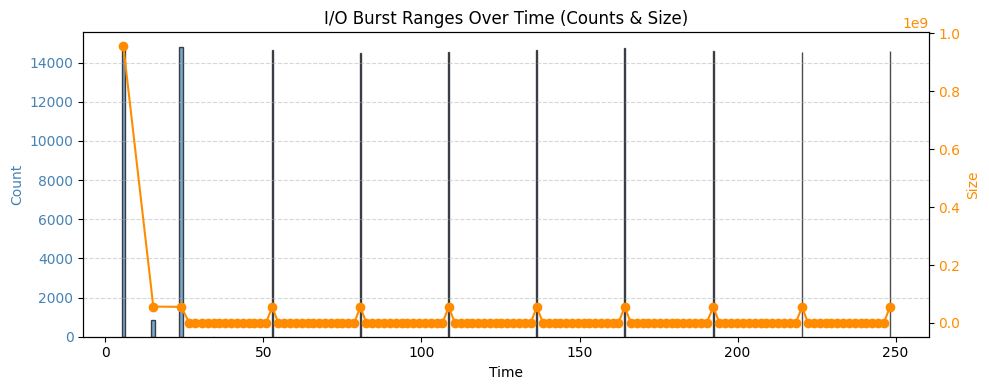

In [7]:
result = merge_close_bursts(result)
result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness1(result)

In [8]:
#write in lustre bigger bursts
result[result['count']>12000]

,start_time,end_time,dur,size,count,ts,te
0,5137206,6252331,607247,956088272,14810,5.137206,6.252331
2,23415351,24515941,745773,55350634,14799,23.415351,24.515941
17,52669076,52902127,476320,54779563,14661,52.669076,52.902127
32,80541825,80765475,474208,54123707,14491,80.541825,80.765475
47,108491661,108715374,478659,54229867,14523,108.491661,108.715374
62,136375994,136604998,475327,54624235,14624,136.375994,136.604998
77,164177531,164404420,475992,55143723,14756,164.177531,164.404420
92,192200845,192428557,480328,54462123,14579,192.200845,192.428557
107,220258064,220482284,474374,54267515,14534,220.258064,220.482284
122,248081695,248312110,477160,54488195,14585,248.081695,248.312110


In [9]:
#write in lustre bigger bursts
result[result['count']<2000]

,start_time,end_time,dur,size,count,ts,te
1,14541199,15802090,381893,56333728,874,14.541199,15.802090
3,26570802,26573543,848,11722,5,26.570802,26.573543
4,28492863,28494886,99,11722,5,28.492863,28.494886
5,30444457,30446159,127,11722,5,30.444457,30.446159
6,32342741,32345064,79,11722,5,32.342741,32.345064
...,...,...,...,...,...,...,...
117,238912152,238916342,1989,11722,5,238.912152,238.916342
118,240739611,240741978,78,11722,5,240.739611,240.741978
119,242571661,242573905,127,11722,5,242.571661,242.573905
120,244402386,244404551,78,11722,5,244.402386,244.404551


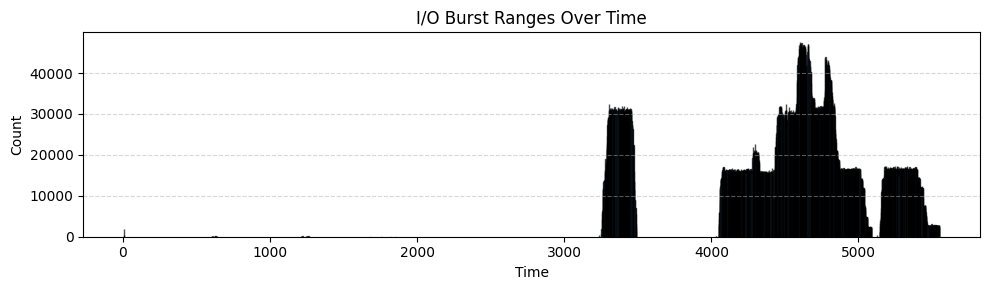

In [54]:
selected_events = df[
    (df['mount_point'] == "/usr/WS2") & (df['name'] == "read")
 ].reset_index(drop=True)

result = selected_events.groupby(['b_id']).agg(
    start_time=('ts', 'min'),
    end_time=('te', 'max'),
    dur = ('dur','sum'),
    size = ('size','sum'),
    count=('ts', 'count')  # or any column — all rows per group are counted
).reset_index()

result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness(result)

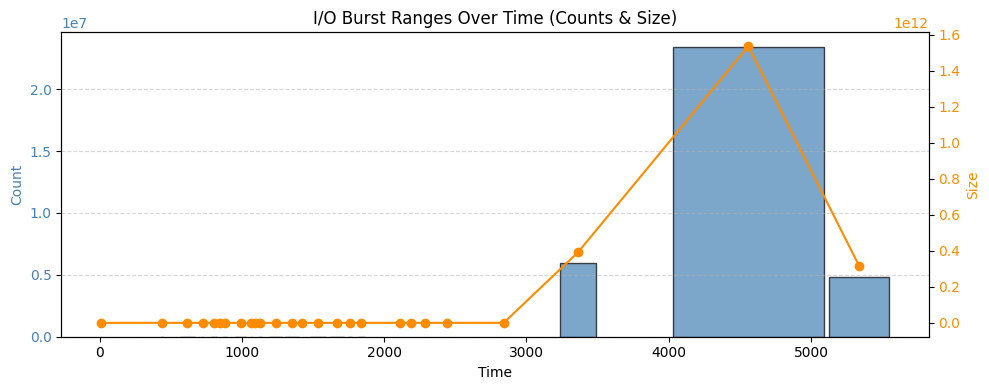

In [55]:
result = merge_close_bursts(result)
result['ts'] = result['start_time']/1e6
result['te'] = result['end_time']/1e6
plot_burstiness1(result)

In [57]:
result[result['count']>.25e7]

,start_time,end_time,dur,size,count,ts,te
23,3235432128,3488624466,108796837,391731445956,5978086,3235.432128,3488.624466
24,4029713289,5087846866,430152921,1535364186798,23430383,4029.713289,5087.846866
25,5126014297,5548895471,97240974,316865364066,4835351,5126.014297,5548.895471


In [16]:
filtered = result[result['count']>10]
filtered['burst_duration'] = filtered['te']-filtered['ts']
filtered

/var/tmp/pandey2/ipykernel_810323/1186137888.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['burst_duration'] = filtered['te']-filtered['ts']


,start_time,end_time,dur,size,count,ts,te,burst_duration
0,5137206,6252331,607247,956088272,14810,5.137206,6.252331,1.115125
1,14541199,15802090,381893,56333728,874,14.541199,15.80209,1.260891
2,23415351,24515941,745773,55350634,14799,23.415351,24.515941,1.10059
17,52669076,52902127,476320,54779563,14661,52.669076,52.902127,0.233051
32,80541825,80765475,474208,54123707,14491,80.541825,80.765475,0.22365
47,108491661,108715374,478659,54229867,14523,108.491661,108.715374,0.223713
62,136375994,136604998,475327,54624235,14624,136.375994,136.604998,0.229004
77,164177531,164404420,475992,55143723,14756,164.177531,164.40442,0.226889
92,192200845,192428557,480328,54462123,14579,192.200845,192.428557,0.227712
107,220258064,220482284,474374,54267515,14534,220.258064,220.482284,0.22422
